<a href="https://colab.research.google.com/github/Ilhomjonewuu/CS102_week3/blob/main/teaching/data-science-fundamentals/materials/student/Lab_01_Rows_Joins_Missingness_Student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 1: Connecting two tables, one step at a time

**CS203 Data Science Fundamentals | Uses Week 1 lecture material**  
**Duration:** 2 hours | **Submit:** one executed notebook by 23:59

You do not need to write a full program today. Read each short code cell, predict what it will do, run it, inspect the output, and answer the question below it.

You will use two tables:

- students: one row is one student;
- enrolments: one row is one student registered in one course.

The central skill is simple: before connecting tables, say what one row means in each table.

## Your route through the lab

| Part | Time | What you do |
| --- | ---: | --- |
| 1. Look | 0:00-0:25 | Run cells and identify rows, columns, and keys |
| 2. Predict | 0:25-0:40 | Decide what should happen when two tables connect |
| 3. Connect | 0:40-1:05 | Complete one short merge and check the row count |
| 4. Summarise | 1:05-1:30 | Complete one group summary and explain its denominator |
| 5. Challenge | 1:30-1:50 | Change one group variable and interpret carefully |
| 6. Explain | 1:50-2:00 | Peer check, final explanation, restart and run all |

There are **10 code cells**. Six are fully provided. You complete four tiny code tasks by replacing one blank or one variable name.

In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

RAW_BASE = "https://raw.githubusercontent.com/Sabokrou/Sabokrou.github.io/main/teaching/data-science-fundamentals/datasets"

def load_table(name):
    local = Path("data") / name
    if local.exists():
        return pd.read_csv(local)
    return pd.read_csv(f"{RAW_BASE}/{name}")

students = load_table("students.csv")
enrolments = load_table("enrolments.csv")

print("students:", students.shape)
print("enrolments:", enrolments.shape)

students: (1200, 7)
enrolments: (4665, 5)


## Part 1: Look at the first table

Before running the next cell, predict:

- How many rows do you expect in students? Answer: 5 rows, indexed 0 to 4.
- Can the same student ID appear more than once? Answer: No, since students is a table where each row represents a single student, each student_id must be unique and appear only once.
- Which columns describe a student rather than identify a student? Answer: While student_id identifies the student, the columns that describe their attributes and enrolment details are: programme, entry_cohort, entry_score, study_mode, age_at_entry, first_generation.

In [3]:
students.head()

,student_id,programme,entry_cohort,entry_score,study_mode,age_at_entry,first_generation
0,100001,Biology,2026,62.3,Full-time,22,False
1,100002,Biology,2026,62.7,Part-time,34,False
2,100003,Economics,2026,73.8,Full-time,20,True
3,100004,Computer Science,2025,62.7,Full-time,23,False
4,100005,Computer Science,2024,51.8,Part-time,30,False


In [4]:
print("Is student_id unique in students?", students["student_id"].is_unique)
print("Number of students:", len(students))
print("Columns:", list(students.columns))

Is student_id unique in students? True
Number of students: 1200
Columns: ['student_id', 'programme', 'entry_cohort', 'entry_score', 'study_mode', 'age_at_entry', 'first_generation']


### Explain after running

1. **What does one row in students represent?** _Write one sentence._
_Answer: One row in the students table represents a single individual student along with their demographic and enrolment details._
2. **Why is student_id an identifier rather than a useful numerical measurement?** _Write one sentence._
Answer: The student_id is an identifier because it serves as a unique label to distinguish students, and performing mathematical operations (like calculating an average)
3. **Choose one column and name its measurement type:** nominal category, number, or identifier. _Write one sentence._
_Answer: The entry_score column represents a number measurement type as it quantitative data._

In [6]:
# TODO 1 - Replace the blank with the table that has one row per student.
# Choose exactly one: students   or   enrolments

one_student_table = students
one_student_table[["student_id", "programme", "study_mode"]].head()

,student_id,programme,study_mode
0,100001,Biology,Full-time
1,100002,Biology,Part-time
2,100003,Economics,Full-time
3,100004,Computer Science,Full-time
4,100005,Computer Science,Part-time


## Part 2: Look at the second table

Run the next cell. Then compare it with students.

**Predict first:** Should student_id still be unique here? Why or why not? Answer: No, student_id should not be unique in this table.   Why:Each row in the enrolments table represents a single course enrollment rather than a student. Because a single student can enroll in multiple courses across different terms, the same student_id will appear multiple times.

In [7]:
print(enrolments.head())
print("Is student_id unique in enrolments?", enrolments["student_id"].is_unique)
print("Number of enrolment rows:", len(enrolments))
print("Number of different students:", enrolments["student_id"].nunique())
print("Courses:", sorted(enrolments["course_code"].unique()))

   student_id course_code     term  final_grade  passed
0      100001       BI101  2026-T3         55.5    True
1      100001       BI102  2026-T3         53.1    True
2      100001       CH110  2026-T3         25.4   False
3      100001       DS100  2026-T3         72.1    True
4      100002       BI101  2026-T3         74.0    True
Is student_id unique in enrolments? False
Number of enrolment rows: 4665
Number of different students: 1200
Courses: ['BI101', 'BI102', 'CH110', 'CS101', 'CS102', 'DS100', 'EC101', 'EC102', 'MA110', 'PS101', 'PS102', 'ST110']


### Explain after running

1. **What does one row in enrolments represent?** _Write one sentence._
Answer: One row in enrolments represents a single course registration by a student, including its term, final grade, and pass status.
2. **Why can student_id repeat in enrolments without being an error?** _Write one sentence._
Answer: The student_id can repeat because a single student can enroll in multiple different courses over time.
3. **Which table should be on the left if your final table needs one row per course registration?** _Write one sentence._
Answer: The enrolments table should be on the left when performing the join.

## Part 3: Connect the tables

We want one row per **course registration**, plus the student's programme and study mode.

- enrolments stays on the left because it already has one row per registration.
- students supplies extra student information.
- many_to_one means many enrolment rows can match one student row.

**Predict:** The merge should have the same number of rows as enrolments. Why? Left Join (how="left"): A left join keeps every row from the left table (enrolments) intact.   Unique Student Keys (validate="many_to_one"): Every student_id in one_student_table appears exactly once. As a result, each row in enrolments matches with at most one row from one_student_table, so no extra row duplicates are created during the merge.  

In [8]:
# TODO 2 - Complete the merge by replacing the blank with one_student_table.
# Do not change on, how, or validate.

joined = enrolments.merge(one_student_table[["student_id", "programme", "study_mode"]],
    on="student_id",
    how="left",
    validate="many_to_one",
)

joined.head()

,student_id,course_code,term,final_grade,passed,programme,study_mode
0,100001,BI101,2026-T3,55.5,True,Biology,Full-time
1,100001,BI102,2026-T3,53.1,True,Biology,Full-time
2,100001,CH110,2026-T3,25.4,False,Biology,Full-time
3,100001,DS100,2026-T3,72.1,True,Biology,Full-time
4,100002,BI101,2026-T3,74.0,True,Biology,Part-time


In [9]:
print("Rows before merge:", len(enrolments))
print("Rows after merge: ", len(joined))
assert len(joined) == len(enrolments), "Unexpected row change: stop and ask for help."
assert joined["programme"].notna().all(), "A student did not match: stop and ask for help."

print("Check passed: one row still represents one student-course registration.")

Rows before merge: 4665
Rows after merge:  4665
Check passed: one row still represents one student-course registration.


### Explain after connecting

1. **After the merge, what does one row in joined represent?**
2. **Why does the row count stay the same?**
3. **What would it mean if the merge created twice as many rows?**
4. **Why is many_to_one appropriate here?**

> Answer each in one short sentence.
1. One row in joined represents a single course registration along with the student's programme and study mode details.
2. The row count stays the same because every enrolment record matches with exactly one unique student profile in the right table.
3. It would mean that duplicate student records existed in the right table, causing each course registration to be matched and duplicated twice.
4. It is appropriate because multiple course enrolment records (many) map to a single unique student record (one).


## Part 4: Make one simple summary

The next task calculates a **course-registration pass rate** by study mode.

This denominator is enrolments, not students. A student taking four courses contributes four registration rows.

**Predict:** Is this the same as “the percentage of students who passed”? Explain before you run the code.

No, it is not the same as "the percentage of students who passed."   Explanation: The course-registration pass rate measures the percentage of individual course enrollments that resulted in a passing grade, where a single student taking multiple courses contributes multiple times to the total count. In contrast, the percentage of students who passed measures unique individual students who met a passing criteria (for instance, passing all or at least one of their courses).

In [11]:
# TODO 3 - Replace the blank with the column that divides rows into full-time and part-time groups.
# Hint: look at one_student_table.head().

pass_rate_by_mode = (
    joined.groupby('study_mode')["passed"]
    .agg(n="size", pass_rate="mean")
    .assign(pass_rate=lambda x: (100 * x["pass_rate"]).round(1))
    .reset_index()
)
pass_rate_by_mode

,study_mode,n,pass_rate
0,Full-time,4108,74.5
1,Part-time,557,77.0


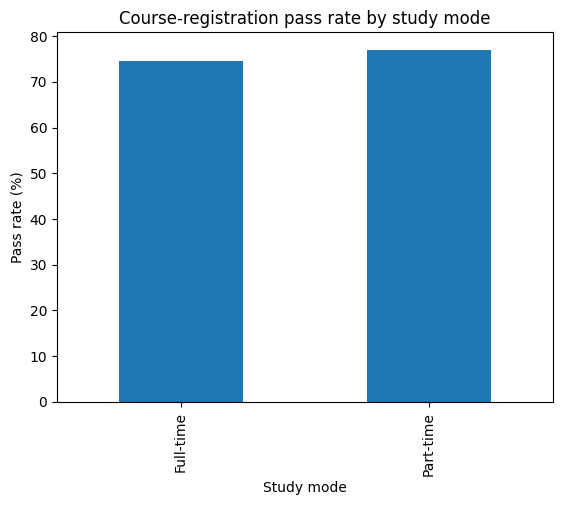

In [12]:
ax = pass_rate_by_mode.plot.bar(
    x="study_mode", y="pass_rate", legend=False,
    title="Course-registration pass rate by study mode"
)
ax.set_ylabel("Pass rate (%)")
ax.set_xlabel("Study mode")
plt.show()

### Explain the output

1. Report the two group sizes and pass rates.
2. State the denominator in plain English.
3. Complete this sentence:

> “In this dataset, the course-registration pass rates differ by study mode. This describes ________. It does not prove that ________.”

4. Give one possible reason, other than study mode itself, that could help explain a difference.
5. Answers:\
1.Report the two group sizes and pass rates:Full-time: Group size ($n$) = 4,108, Pass rate = 74.5%   Part-time: Group size ($n$) = 557, Pass rate = 77.0%\
2.State the denominator in plain English:
The total number of course registrations (enrolments), not the total number of individual students.\
3.Complete this sentence:
"In this dataset, the course-registration pass rates differ by study mode. This describes an observed association/correlation in the data. It does not prove that study mode causes the difference in pass rates."\
4.Give one possible reason, other than study mode itself, that could help explain a difference:
Part-time students might take fewer courses at a time, allowing them to focus more attention and time on each individual course.

## Part 5: Small challenge

You have already seen the full pattern. Now change **one word** in the code below.

The question is: “How do course-registration pass rates differ by programme?”

- Replace the blank with the correct grouping column.
- Run the cell.
- Make a short chart or use the printed table.
- Explain why the programme with the highest value is not automatically the “best” programme.

- Answers: Different Grading Standards and Difficulty: Programmes differ significantly in course difficulty, assessment methods, and grading criteria. A higher pass rate may reflect easier grading rather than superior programme quality.   
Confounding Variables: Entry criteria (like entry_score), student cohort sizes, and study modes vary across programmes, all of which influence pass rates independently of teaching quality.   
Pass Rate vs. Mastery: A high pass rate only shows that students met a minimum passing threshold, not how deeply or thoroughly they mastered the material.  

In [14]:
# TODO 4 - Replace the blank with the correct column name.
# Hint: the column describes Biology, Computer Science, Economics, or Psychology.

challenge_table = (
    joined.groupby("programme")["passed"]
    .agg(n="size", pass_rate="mean")
    .assign(pass_rate=lambda x: (100 * x["pass_rate"]).round(1))
    .reset_index()
)
challenge_table

,programme,n,pass_rate
0,Biology,1148,73.6
1,Computer Science,1452,77.7
2,Economics,1068,74.2
3,Psychology,997,72.5


## Final thinking task

A manager says: “The programme with the highest pass rate is better, so we should copy its teaching everywhere.”

Write **120-160 words**. Use your challenge table, but answer carefully:

- What does the table show?
- What does one row represent?
- What important information is missing?
- Why does a difference not prove that teaching caused it?
- What would you check next?

> _Write here._
The table shows course-registration pass rates across four academic programmes, ranging from 72.5% in Psychology to 77.7% in Computer Science. Each row represents an aggregated summary of all course registrations within a specific degree programme.   However, the table lacks essential information such as entry qualification scores, assessment difficulty, student workload, and study modes across programmes. An observed difference in pass rates does not prove superior teaching because confounding factors, such as differing grading strictness or baseline student capabilities, could drive these outcomes rather than instructional quality alone.   Before altering teaching methods university-wide, I would analyze incoming student entry scores (entry_score), compare course difficulty levels, control for full-time versus part-time proportions, and gather student feedback. A higher pass rate reflects a statistical correlation, not direct evidence of better teaching.  

## Peer check and submission

Ask a nearby student:

1. What does one row in joined represent?
2. What is the denominator of pass_rate_by_mode?
3. What claim is too strong for this data?

- **Reviewer initials:** _replace_
- **One improvement I made:** _replace_

Before submitting: **Runtime -> Restart session and run all**. All outputs must remain visible.

| Criterion | Weight |
| --- | ---: |
| Rows, tables, and merge explanation | 35% |
| Completed code and reproducible notebook | 25% |
| Correct denominator and summary explanation | 20% |
| Final cautious reasoning task | 15% |
| Peer check and complete submission | 5% |